# Analysis: Model Performance

Here we focus on capturing differences in model performance.

**Performance score** is calculated by:
- train models with inner and outer folds (10 outer folds, with 9 inner folds each)
- measure the cross-entropy, or Negative Log Likelihood (NLL), of next-action predictions in train, val (inner) and eval (outer) datasets.
- for each subject, each outer fold, select the inner fold with lowest NLL across train and inner validation datasets.
- for each subject, we take the mean across outer folds.
- Statistics are done at subject-level: for each subject, we therefore take the mean across outer folds for a subject-level score.


**Architectures** we have trained models which differ in:
- gating mechanisms ['GRU','lightGRU','monoGRU','vanilla']
- dimensionality [1, 2 or 3 hidden units]
- activation function ['relu', 'tanh']
- input encodings ['unipolar','onehot','encoder']
- decoder bias [with or without]

In [51]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
#from NM_TinyRNN.code.measures import reversal_metrics as revme
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df() #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate
best_model_df = perf.select_best_outer(performance_df) #
subject_level_df = perf.compute_outer_mean(best_model_df)

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

print("\nAvailable columns:")
print([col for col in all_models_df.columns if 'CE' in col or 'type' in col])


Loaded analysis paths from cache: NM_TinyRNN/data/analysis/analysis_df.htsv
Loaded performance dataframe from cache: NM_TinyRNN/data/analysis/performance_df.htsv
Available model types (model_type2):
['vanilla+BC' 'vanilla+BC-DB' 'vanilla' 'GRU+BC' 'GRU+BC-DB' 'GRU'
 'lightGRU+BC' 'monoGRU+BC' 'monoGRU+BC-DB' 'monoGRU_abs'
 'monoGRU_no_hidden+BC-DB' 'monoGRU_hidden_only+BC-DB']

Available columns:
['model_type', 'model_type2']


# Main

## Ji-an style plot: comparing 1 and 2 unit models across architectures.


In [54]:
all_models_df.query('subject_id == "WS08" and model_id == "2_unit_GRU_tanh_unipolar_forced"')

,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,save_path,data_path,completed,model_type2,inner_loop_idx,info_path,model_state_path,model_pickle_path,training_losses_path,trials_data_path
6867,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,0,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
6868,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,1,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
6869,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,2,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
6870,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,3,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
6871,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,4,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9832,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,4,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
9833,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,5,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
9834,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,6,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...
9835,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS08,1,GRU,7,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS08/GRU/sp...


In [55]:
performance_df.query('subject_id == "WS08" and model_id == "2_unit_GRU_tanh_unipolar_forced"')

,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,weight_seed,sparsity_lambda,energy_lambda,train_CE,val_CE,train_val_CE,eval_CE_computed,train_n_trials,val_n_trials,eval_n_trials
6867,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,10,0.00001,0.0,0.629506,0.676179,0.635895,0.657480,5330,845,650
6868,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,9,0.00001,0.0,0.594884,0.635557,0.598309,0.642467,5655,520,650
6869,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,3,0.00001,0.0,0.557177,0.589122,0.561881,0.636023,5265,910,650
6870,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,10,0.00001,0.0,0.563640,0.564055,0.563705,0.643388,5200,975,650
6871,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,6,0.00010,0.0,0.569906,0.537434,0.565117,0.639273,5265,910,650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9832,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,2,0.00100,0.0,0.584724,0.566145,0.581881,0.502634,5395,975,455
9833,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,3,0.00001,0.0,0.588026,0.545550,0.581953,0.510230,5460,910,455
9834,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,7,0.00100,0.0,0.588345,0.545217,0.583506,0.506093,5655,715,455
9835,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,3,0.00010,0.0,0.588246,0.516193,0.582363,0.509977,5850,520,455


In [56]:
best_model_df.query('subject_id == "WS08" and model_id == "2_unit_GRU_tanh_unipolar_forced"')

,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,best_val_CE,weight_seed,sparsity_lambda,energy_lambda,train_CE,val_CE,eval_CE_computed,train_n_trials,val_n_trials,eval_n_trials
6869,763,WS08,1,GRU,2,tanh,sparsity,True,unipolar,True,...,0.566076,3,0.00001,0.0,0.557177,0.589122,0.636023,5265,910,650
7202,800,WS08,2,GRU,2,tanh,sparsity,True,unipolar,True,...,0.573335,4,0.00001,0.0,0.548511,0.588932,0.657689,5070,910,845
7535,837,WS08,3,GRU,2,tanh,sparsity,True,unipolar,True,...,0.571612,8,0.00001,0.0,0.563684,0.593013,0.616442,5395,910,520
7873,874,WS08,4,GRU,2,tanh,sparsity,True,unipolar,True,...,0.392163,8,0.00010,0.0,0.572855,0.521515,0.594928,5590,325,910
8203,911,WS08,5,GRU,2,tanh,sparsity,True,unipolar,True,...,0.439355,1,0.00001,0.0,0.583318,0.544031,0.571194,4940,910,975
8539,948,WS08,6,GRU,2,tanh,sparsity,True,unipolar,True,...,0.394075,9,0.00001,0.0,0.583850,0.524244,0.544074,5590,325,910
8872,985,WS08,7,GRU,2,tanh,sparsity,True,unipolar,True,...,0.395718,4,0.00001,0.0,0.581960,0.523035,0.550584,5785,325,715
9193,1022,WS08,8,GRU,2,tanh,sparsity,True,unipolar,True,...,0.498644,7,0.00001,0.0,0.583225,0.566899,0.515211,5330,975,520
9516,1059,WS08,9,GRU,2,tanh,sparsity,True,unipolar,True,...,0.570699,6,0.00010,0.0,0.573949,0.594602,0.524696,5590,910,325
9831,1096,WS08,10,GRU,2,tanh,sparsity,True,unipolar,True,...,0.562432,0,0.00001,0.0,0.577094,0.595461,0.503214,5460,910,455


In [57]:
all_models_df.query('model_id=="2_unit_GRU_tanh_unipolar_forced"')

,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,save_path,data_path,completed,model_type2,inner_loop_idx,info_path,model_state_path,model_pickle_path,training_losses_path,trials_data_path
207,23,WS20,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU,0,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...
208,23,WS20,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU,1,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...
209,23,WS20,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU,2,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...
210,23,WS20,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU,3,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...
211,23,WS20,1,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU,4,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/sp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39748,4426,WS09,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,1,GRU,4,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...
39749,4426,WS09,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,1,GRU,5,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...
39750,4426,WS09,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,1,GRU,6,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...
39751,4426,WS09,10,GRU,2,tanh,sparsity,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,1,GRU,7,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...


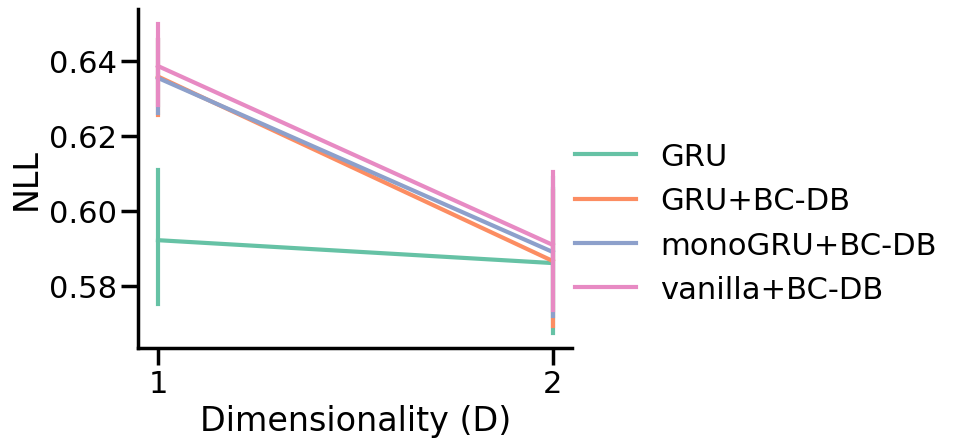

In [58]:


sns.set_context('poster')
model_list = ["GRU", "GRU+BC-DB","monoGRU+BC-DB","vanilla+BC-DB"]
unipolar_models = subject_level_df.query('input_encoding=="unipolar"')
unipolar_models = unipolar_models[unipolar_models.model_type2.isin(model_list)]
#unipolar_models = unipolar_models.query('n_outer_folds==10')

g = sns.relplot(unipolar_models, x='hidden_size',y='eval_CE_computed', kind = 'line', 
                hue= 'model_type2', palette = "Set2",
                err_style = 'bars',
                col_order = ['tanh','relu'],
                hue_order = model_list,
                aspect = 1.4)
g.legend.set(title = '')
g.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)', xticks = [1,2])

## Unipolar models: are 1-unit models better than 2-unit models?

We focus on unipolar encodings, as these were adopted by Ji-an et al., and seem the 'most' biological when considering the temporal separation of different events.



PAIRED COMPARISON DIAGNOSTIC RUN REPORT
        group            test_used                           reason  outliers_present  p_corrected
          GRU Wilcoxon Signed-Rank                Outliers detected              True     0.001465
       GRU+BC        Paired t-test Normal distribution, no outliers             False     0.000033
  lightGRU+BC        Paired t-test Normal distribution, no outliers             False     0.000013
   monoGRU+BC        Paired t-test Normal distribution, no outliers             False     0.000073
monoGRU+BC-DB        Paired t-test Normal distribution, no outliers             False     0.000007
vanilla+BC-DB Wilcoxon Signed-Rank           Non-normal differences             False     0.000586



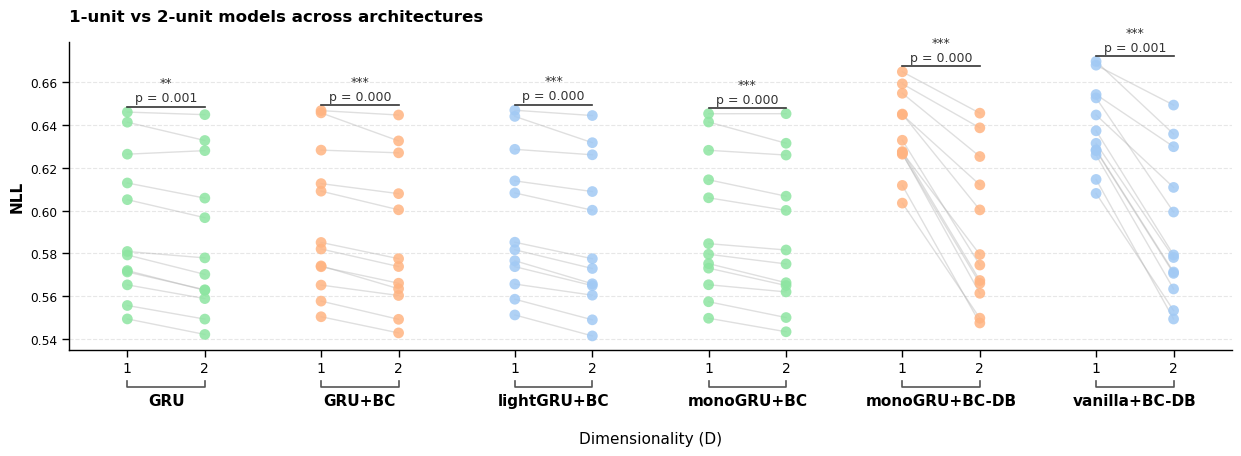

In [64]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
fig, ax = plt.subplots(figsize = (15,4))
select_models = subject_level_df[subject_level_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])
axis, ttest = plotting_stats.plot_paired_comparison(select_models,
                                                y='eval_CE_computed',
                                                x='hidden_size',
                                                within_variable='model_type2', 
                                                paired_across='subject_id',
                                                hue_order = model_list, 
                                                colors = palette, 
                                                ax = ax,
                                                title = "1-unit vs 2-unit models across architectures")

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

## Unipolar 2 unit models: difference across architectures

We want to compare model performance of 2-unit models across the different architectures. Here we preform an ANOVA.




N subjects with complete data: 12

Repeated measures ANOVA:
     Source  ddof1  ddof2         F        p_unc      ng2      eps
model_type2      5     55 14.231181 6.219958e-09 0.002329 0.684911

Post-hoc paired t-tests (fdr_bh corrected):
  vanilla+BC-DB vs monoGRU+BC-DB: t=2.35, mean_diff=0.0019, p_raw=0.0385, p_corr=0.0578 n.s.
  vanilla+BC-DB vs monoGRU+BC: t=3.89, mean_diff=0.0031, p_raw=0.0025, p_corr=0.0076 **
  vanilla+BC-DB vs GRU+BC: t=5.48, mean_diff=0.0037, p_raw=0.0002, p_corr=0.0010 ***
  vanilla+BC-DB vs lightGRU+BC: t=5.47, mean_diff=0.0039, p_raw=0.0002, p_corr=0.0010 ***
  vanilla+BC-DB vs GRU: t=6.04, mean_diff=0.0048, p_raw=0.0001, p_corr=0.0010 ***
  monoGRU+BC-DB vs monoGRU+BC: t=1.53, mean_diff=0.0012, p_raw=0.1553, p_corr=0.1792 n.s.
  monoGRU+BC-DB vs GRU+BC: t=2.89, mean_diff=0.0018, p_raw=0.0148, p_corr=0.0299 *
  monoGRU+BC-DB vs lightGRU+BC: t=3.06, mean_diff=0.0020, p_raw=0.0109, p_corr=0.0273 *
  monoGRU+BC-DB vs GRU: t=3.91, mean_diff=0.0030, p_raw=0.0025

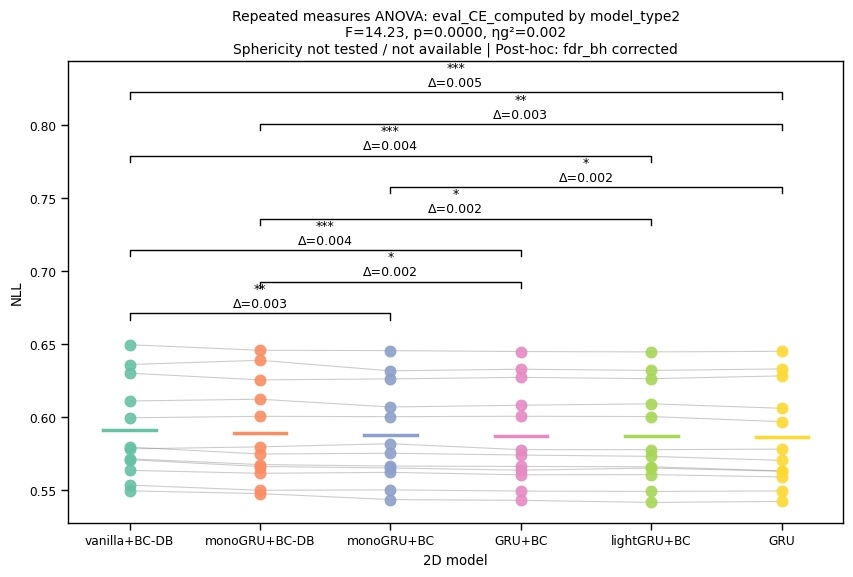

In [73]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
select_models = subject_level_df[subject_level_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')
select_models = select_models.query('hidden_size==2')

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])

fig, ax = plt.subplots(figsize=(10, 6))
anova_result, pair_results, ax = plotting_stats.plot_repeated_measures_anova(select_models,
                                            y='eval_CE_computed',
                                            x='model_type2',
                                            paired_across='subject_id',
                                            mean_across=None,ax=ax)
ax.set(xlabel='2D model', ylabel='NLL')

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

      model_a       model_b  n_subjects  statistic  p_value  median_difference  p_adjusted
          GRU vanilla+BC-DB          12        0.0 0.000488          -0.004494    0.007324
       GRU+BC vanilla+BC-DB          12        2.0 0.001465          -0.003652    0.007324
  lightGRU+BC vanilla+BC-DB          12        2.0 0.001465          -0.004185    0.007324
  lightGRU+BC monoGRU+BC-DB          12        3.0 0.002441          -0.001319    0.009155
   monoGRU+BC vanilla+BC-DB          12        5.0 0.004883          -0.004063    0.012207
          GRU monoGRU+BC-DB          12        5.0 0.004883          -0.003458    0.012207
       GRU+BC monoGRU+BC-DB          12        8.0 0.012207          -0.001151    0.026158
          GRU    monoGRU+BC          12       11.0 0.026855          -0.001753    0.050354
monoGRU+BC-DB vanilla+BC-DB          12       12.0 0.034180          -0.002794    0.056966
          GRU        GRU+BC          12       17.0 0.092285          -0.000731    0.138428

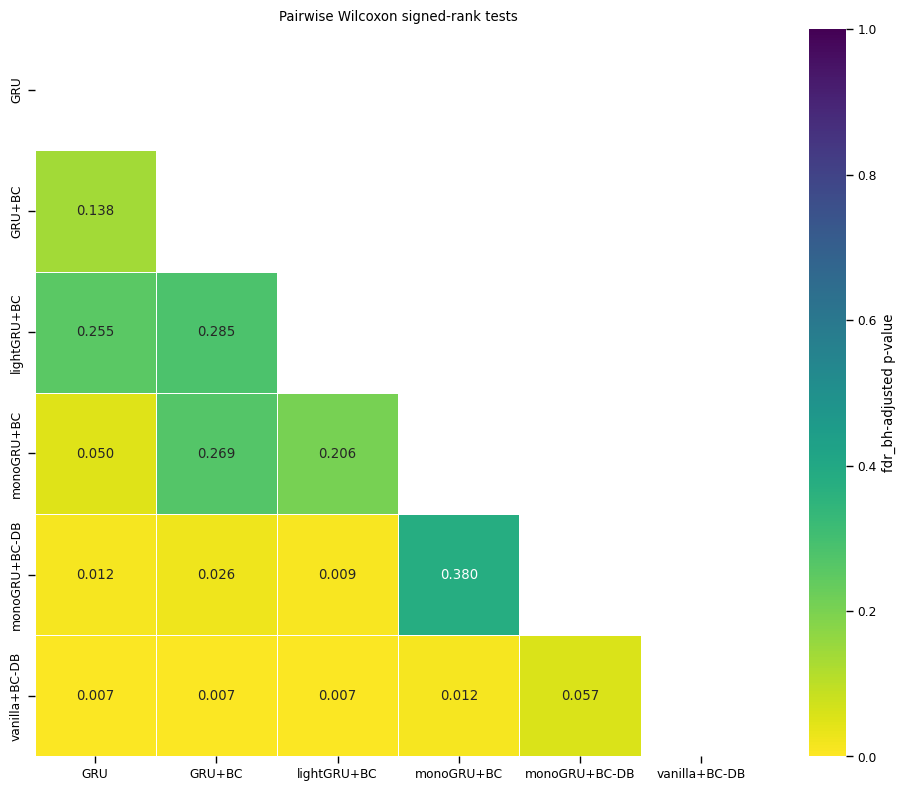

In [74]:
# Pairwise subject-level comparison of all selected models
reload(plotting_stats)
sns.set_context('paper')
model_list = [
    'GRU', 'GRU+BC', 'lightGRU+BC',
    'monoGRU+BC', 'monoGRU+BC-DB', 'vanilla+BC-DB',
]

models = subject_level_df.query(
    'hidden_size == 2 and input_encoding == "unipolar"'
).loc[lambda dataframe: dataframe.model_type2.isin(model_list)]

fig, ax = plt.subplots(figsize=(10, 8))
ax, pairwise_results = plotting_stats.plot_pairwise_wilcoxon(
    models,
    value_col='eval_CE_computed',
    model_order=model_list,
    ax=ax,
)
print(pairwise_results.sort_values('p_adjusted').to_string(index=False))
plt.tight_layout()
plt.show()


# Supplementary

Here we include further explorations which supplement the primary narrative of the paper

## per-subject inner x outer loop losses

We are interested in knowing whether there's a trend towards some folds having worse fits.

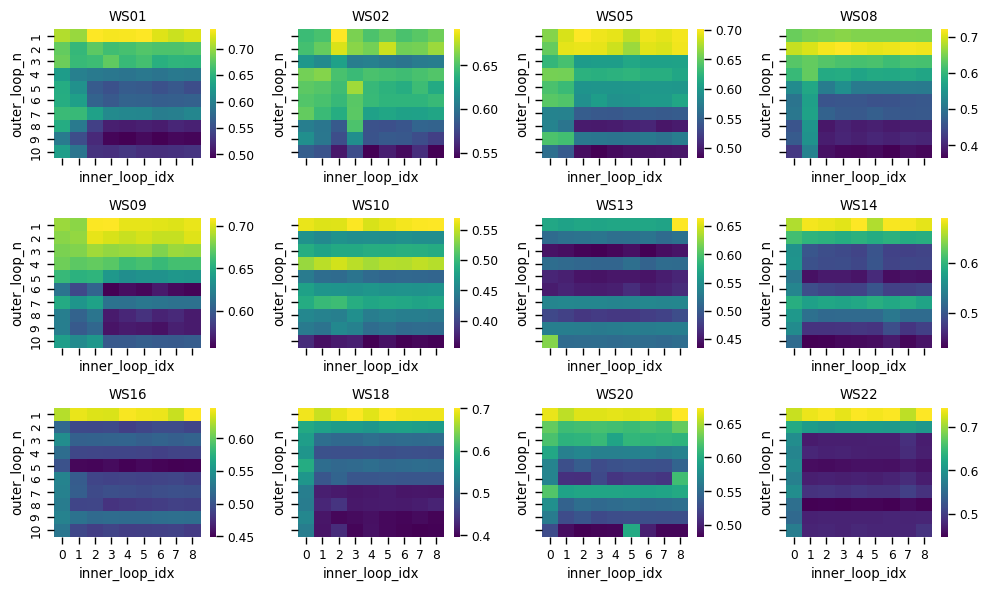

In [74]:
# for example, let's select a particular model
sns.set_context('paper')
model_id = '2_unit_monoGRU_relu_unipolar_forced_ndb' #minimal variation monoGRU
model_df = all_models_df.query(f'model_id=="{model_id}"')
fig, ax = plt.subplots(3,4, figsize = (10,6), sharex = True, sharey=True)
flat_ax = ax.flatten()
for i, each_subject in enumerate(model_df.subject_id.unique()):
    subject_df = model_df.query(f'subject_id=="{each_subject}"')
    pivot_df = subject_df.pivot(index="outer_loop_n",columns = "inner_loop_idx",values="eval_CE")
    sns.heatmap(pivot_df, ax=flat_ax[i], cmap='viridis')
    flat_ax[i].set_title(f'{each_subject}')
    
fig.tight_layout()

## Exploring the role of input encodings

